In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os
import time
from glob import glob
import matplotlib.pyplot as plt

In [2]:
tf.random.set_seed(42)
BATCH_SIZE = 128
IMG_SIZE = 64
CHANNELS = 3
NOISE_DIM = 100
EPOCHS = 100
BUFFER_SIZE = 200000

[Link Data](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset?resource=download)

In [3]:
def load_celeba_images(image_paths):
    def preprocess_image(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = (img - 127.5) / 127.5   # Normaliza [-1,1]
        return img

    dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

image_paths = glob("../data/img_align_celeba/*.jpg")
train_dataset = load_celeba_images(image_paths)


I0000 00:00:1770338583.853415   69451 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13568 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


In [4]:
train_dataset

<_PrefetchDataset element_spec=TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None)>

In [5]:
8*8*512

32768

In [13]:
256 *2 

512

In [18]:
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*512, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((8, 8, 512)))

    model.add(layers.Conv2DTranspose(256, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(CHANNELS, (5,5), strides=(1,1), padding='same', activation='tanh'))
    return model

generator = make_generator_model()

In [19]:
generator.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32768)          │     3,276,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 16, 16, 256)    │     1,179,648 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 32, 32, 128)    │       294,912 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 64, 64, 64)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 64, 64, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,959,683 (18.92 MB)

 Trainable params: 4,893,251 (18.67 MB)

 Non-trainable params: 66,432 (259.50 KB)

In [5]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[IMG_SIZE, IMG_SIZE, CHANNELS]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

discriminator = make_discriminator_model()

/home/gibran/anaconda3/envs/tf219/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

In [7]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)

In [8]:
@tf.function
def train_step(images):
    noise = tf.random.normal([tf.shape(images)[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [9]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        for image_batch in dataset:
            train_step(image_batch)

        print (f'Epoch {epoch+1} completed in {time.time()-start:.2f}s')
        checkpoint.save(file_prefix = checkpoint_prefix)

train(train_dataset, EPOCHS)

E0000 00:00:1770249800.525209  165574 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1770249800.756031  167501 cuda_dnn.cc:529] Loaded cuDNN version 91001
E0000 00:00:1770249885.030550  165574 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-02-04 18:04:46.484897: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1 completed in 95.82s


2026-02-04 18:06:14.904410: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2 completed in 89.00s
Epoch 3 completed in 86.49s


2026-02-04 18:09:07.613750: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Epoch 16 completed in 84.74s
Epoch 17 completed in 84.38s
Epoch 18 completed in 84.20s
Epoch 19 completed in 84.34s
Epoch 20 completed in 84.47s
Epoch 21 completed in 84.34s
Epoch 22 completed in 84.26s
Epoch 23 completed in 84.13s
Epoch 24 completed in 84.50s
Epoch 25 completed in 84.26s
Epoch 26 completed in 84.36s
Epoch 27 completed in 84.22s
Epoch 28 completed in 84.38s
Epoch 29 completed in 84.27s
Epoch 30 completed in 84.40s
Epoch 31 completed in 84.29s


2026-02-04 18:48:48.196682: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 32 completed in 84.25s
Epoch 33 completed in 84.28s
Epoch 34 completed in 83.96s
Epoch 35 completed in 84.04s
Epoch 36 completed in 84.13s
Epoch 37 completed in 84.11s
Epoch 38 completed in 84.06s
Epoch 39 completed in 84.04s
Epoch 40 completed in 83.95s
Epoch 41 completed in 84.00s
Epoch 42 completed in 83.74s
Epoch 43 completed in 84.39s
Epoch 44 completed in 84.01s
Epoch 45 completed in 84.06s
Epoch 46 completed in 83.99s
Epoch 47 completed in 83.90s
Epoch 48 completed in 83.85s
Epoch 49 completed in 83.88s
Epoch 50 completed in 83.58s
Epoch 51 completed in 83.47s
Epoch 52 completed in 83.71s
Epoch 53 completed in 83.75s
Epoch 54 completed in 84.15s
Epoch 55 completed in 84.12s
Epoch 56 completed in 83.75s
Epoch 57 completed in 83.69s
Epoch 58 completed in 83.75s
Epoch 59 completed in 83.66s
Epoch 60 completed in 83.58s
Epoch 61 completed in 84.23s
Epoch 62 completed in 83.99s
Epoch 63 completed in 83.78s


2026-02-04 19:33:42.871793: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 64 completed in 84.00s
Epoch 65 completed in 83.68s
Epoch 66 completed in 83.51s
Epoch 67 completed in 83.63s
Epoch 68 completed in 83.91s
Epoch 69 completed in 83.66s
Epoch 70 completed in 83.68s
Epoch 71 completed in 83.62s
Epoch 72 completed in 83.70s
Epoch 73 completed in 83.70s
Epoch 74 completed in 83.76s
Epoch 75 completed in 83.60s
Epoch 76 completed in 83.72s
Epoch 77 completed in 83.72s
Epoch 78 completed in 83.62s
Epoch 79 completed in 83.50s
Epoch 80 completed in 83.99s
Epoch 81 completed in 83.54s
Epoch 82 completed in 83.45s
Epoch 83 completed in 83.44s
Epoch 84 completed in 83.44s
Epoch 85 completed in 83.60s
Epoch 86 completed in 83.50s
Epoch 87 completed in 83.63s
Epoch 88 completed in 83.51s
Epoch 89 completed in 83.49s
Epoch 90 completed in 83.52s
Epoch 91 completed in 83.58s
Epoch 92 completed in 84.10s
Epoch 93 completed in 83.56s
Epoch 94 completed in 83.48s
Epoch 95 completed in 83.59s
Epoch 96 completed in 83.52s
Epoch 97 completed in 83.47s
Epoch 98 compl

In [10]:
def generate_faces(model, num_images=16):
    noise = tf.random.normal([num_images, NOISE_DIM])
    imgs = model(noise, training=False)
    imgs = (imgs + 1) / 2.0
    fig = plt.figure(figsize=(4,4))
    for i in range(num_images):
        plt.subplot(4,4,i+1)
        plt.imshow(imgs[i])
        plt.axis('off')
    plt.show()

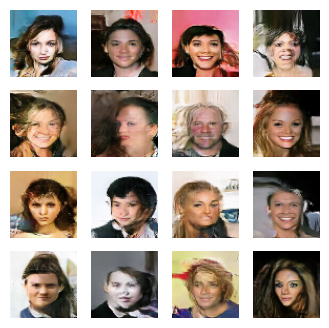

In [11]:
generate_faces(generator, num_images=16)